# Avaliação Prática 2 - Inteligência Artificial e Aprendizado de Máquina
Caio dos Santos Cunha

Guilherme Giusepe Piovezan

Jhenifer Laís Barbosa

## Configuração Inicial - Imports e Semente

In [1]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import pandas as pd
import copy
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

random_state = 2025
random.seed(random_state)
np.random.seed(random_state)
torch.manual_seed(random_state)
torch.cuda.manual_seed_all(random_state)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dispositivo:', DEVICE)

Dispositivo: cuda


## 1) Leitura e Organização do Dataset dfgen

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Total de amostras: 60000
Forma das imagens: (60000, 32, 32, 3)
Forma dos labels:  (60000,)

Contagem por classe:
    Classe  Total
  airplane   6000
automobile   6000
      bird   6000
       cat   6000
      deer   6000
       dog   6000
      frog   6000
     horse   6000
      ship   6000
     truck   6000


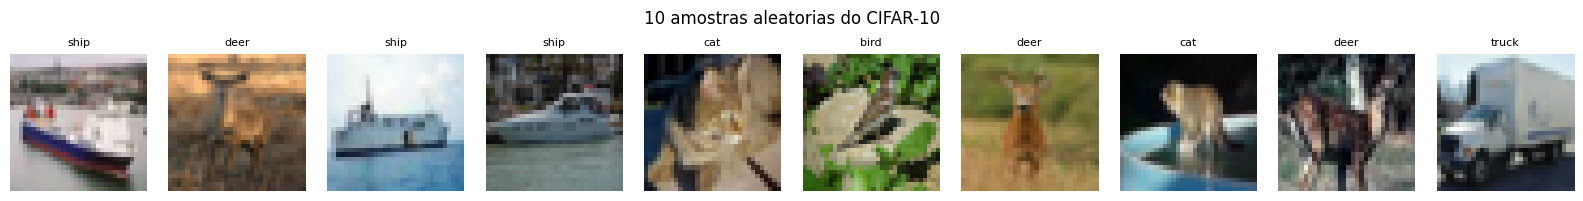

In [2]:
class CIFAR10Dataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.features = images
        self.labels   = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.features[idx]
        lbl = int(self.labels[idx])
        if self.transform:
            img = self.transform(img)
        return img, lbl


cifar10_raw = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True)
cifar10_test_raw = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)

CLASS_NAMES = cifar10_raw.classes
print('Classes:', CLASS_NAMES)

all_images = np.concatenate([cifar10_raw.data, cifar10_test_raw.data], axis=0)
all_labels = np.array(cifar10_raw.targets + cifar10_test_raw.targets)

dfgen = CIFAR10Dataset(all_images, all_labels)

print('Total de amostras:', len(dfgen))
print('Forma das imagens:', dfgen.features.shape)
print('Forma dos labels: ', dfgen.labels.shape)

unique, counts = np.unique(dfgen.labels, return_counts=True)
df_count = pd.DataFrame({'Classe': [CLASS_NAMES[i] for i in unique], 'Total': counts})
print('\nContagem por classe:')
print(df_count.to_string(index=False))

rng = np.random.default_rng(random_state)
sample_idx = rng.choice(len(dfgen), size=10, replace=False)

fig, axes = plt.subplots(1, 10, figsize=(16, 2))
fig.suptitle('10 amostras aleatorias do CIFAR-10')
for ax, idx in zip(axes, sample_idx):
    ax.imshow(dfgen.features[idx])
    ax.set_title(CLASS_NAMES[dfgen.labels[idx]], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 2) Pré-processamento e Data Augmentation

In [3]:
transform_train = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

transform_eval = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

print('transform_train:', transform_train)
print('transform_eval: ', transform_eval)

transform_train: Compose(
    ToPILImage()
    RandomCrop(size=(32, 32), padding=4)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
    ToTensor()
    Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
)
transform_eval:  Compose(
    ToPILImage()
    ToTensor()
    Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
)


## 3) Divisão dos Dados em Treino / Validação / Teste

In [4]:
indices = np.arange(len(dfgen))

idx_trainval, idx_test = train_test_split(
    indices,
    test_size=0.15,
    stratify=dfgen.labels,
    random_state=random_state
)
idx_train, idx_val = train_test_split(
    idx_trainval,
    test_size=0.15 / 0.85,
    stratify=dfgen.labels[idx_trainval],
    random_state=random_state
)

print('Treino    :', len(idx_train))
print('Validação :', len(idx_val))
print('Teste     :', len(idx_test))

rows = []
for cls_id, cls_name in enumerate(CLASS_NAMES):
    n_train = int(np.sum(dfgen.labels[idx_train] == cls_id))
    n_val   = int(np.sum(dfgen.labels[idx_val]   == cls_id))
    n_test  = int(np.sum(dfgen.labels[idx_test]  == cls_id))
    rows.append({'Classe': cls_name, 'Treino': n_train, 'Validacao': n_val, 'Teste': n_test})

df_split = pd.DataFrame(rows)
df_split.loc[len(df_split)] = ['TOTAL', df_split['Treino'].sum(), df_split['Validacao'].sum(), df_split['Teste'].sum()]
print('\nAmostras por classe:')
print(df_split.to_string(index=False))

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(random_state)

ds_train = CIFAR10Dataset(dfgen.features[idx_train], dfgen.labels[idx_train], transform_train)
ds_val   = CIFAR10Dataset(dfgen.features[idx_val],   dfgen.labels[idx_val],   transform_eval)
ds_test  = CIFAR10Dataset(dfgen.features[idx_test],  dfgen.labels[idx_test],  transform_eval)

BATCH_SIZE = 128
loader_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, worker_init_fn=seed_worker, generator=g)
loader_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
loader_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print('\nBatches por epoca (treino):', len(loader_train))

Treino    : 42000
Validação : 9000
Teste     : 9000

Amostras por classe:
    Classe  Treino  Validacao  Teste
  airplane    4200        900    900
automobile    4200        900    900
      bird    4200        900    900
       cat    4200        900    900
      deer    4200        900    900
       dog    4200        900    900
      frog    4200        900    900
     horse    4200        900    900
      ship    4200        900    900
     truck    4200        900    900
     TOTAL   42000       9000   9000

Batches por epoca (treino): 329


## 4) Arquitetura da CNN - clfgen

In [5]:
class ClfGen(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,  32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4   = nn.BatchNorm2d(64)
        self.pool  = nn.MaxPool2d(2, 2)
        self.drop1 = nn.Dropout(0.3)
        self.fc1   = nn.Linear(64 * 8 * 8, 256)
        self.drop2 = nn.Dropout(0.5)
        self.fc2   = nn.Linear(256, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = self.drop1(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.drop2(x)
        x = self.fc2(x)
        return x


clfgen = ClfGen().to(DEVICE)
print(clfgen)
print('\nParametros treinaveis:', sum(p.numel() for p in clfgen.parameters() if p.requires_grad))

ClfGen(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=4096, out_features=256, bias=True)
  (drop2): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

Parametros treinaveis: 1117354


## 5) Treinamento com Validação

epoca   1  lr=0.001000  loss_tr=1.7214  acc_tr=0.3614  loss_val=1.2782  acc_val=0.5280  *
epoca   2  lr=0.001000  loss_tr=1.4166  acc_tr=0.4843  loss_val=1.0818  acc_val=0.6107  *
epoca   3  lr=0.001000  loss_tr=1.2577  acc_tr=0.5453  loss_val=0.9833  acc_val=0.6496  *
epoca   4  lr=0.001000  loss_tr=1.1659  acc_tr=0.5864  loss_val=0.9835  acc_val=0.6552  *
epoca   5  lr=0.001000  loss_tr=1.0963  acc_tr=0.6098  loss_val=0.8292  acc_val=0.7039  *
epoca   7  lr=0.001000  loss_tr=1.0123  acc_tr=0.6429  loss_val=0.7853  acc_val=0.7276  *
epoca  10  lr=0.001000  loss_tr=0.9281  acc_tr=0.6759  loss_val=0.8039  acc_val=0.7201  
epoca  12  lr=0.001000  loss_tr=0.8875  acc_tr=0.6922  loss_val=0.6737  acc_val=0.7620  *
epoca  14  lr=0.001000  loss_tr=0.8532  acc_tr=0.7018  loss_val=0.6669  acc_val=0.7689  *
epoca  15  lr=0.001000  loss_tr=0.8318  acc_tr=0.7104  loss_val=0.6463  acc_val=0.7707  *
epoca  17  lr=0.001000  loss_tr=0.8106  acc_tr=0.7203  loss_val=0.6668  acc_val=0.7750  *
epoca  18  

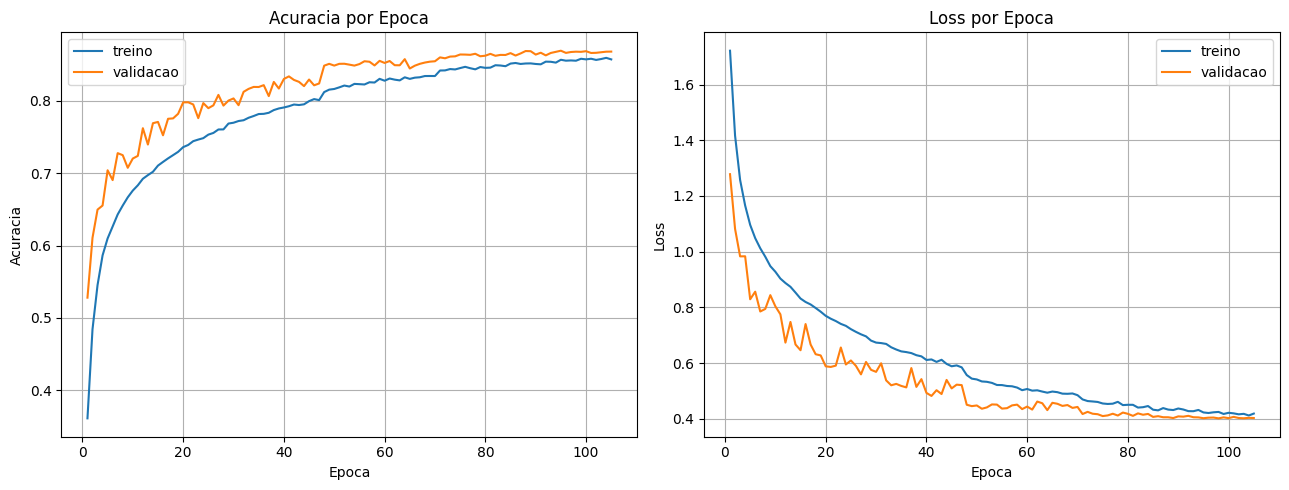

In [8]:
torch.manual_seed(random_state)
clfgen = ClfGen().to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(clfgen.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

MAX_EPOCHS     = 150
EARLY_PATIENCE = 10
MODEL_PATH     = 'best_clfgen.pth'

best_val_acc   = 0.0
patience_count = 0

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}


def run_epoch(model, loader, training=True):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            if training:
                optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += images.size(0)
    return total_loss / total, correct / total


for epoch in range(1, MAX_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(clfgen, loader_train, training=True)
    vl_loss, vl_acc = run_epoch(clfgen, loader_val,   training=False)
    scheduler.step(vl_acc)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    lr = optimizer.param_groups[0]['lr']

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(copy.deepcopy(clfgen.state_dict()), MODEL_PATH)
        patience_count = 0
        tag = '*'
    else:
        patience_count += 1
        tag = ''

    if epoch % 5 == 0 or tag:
        print(f'epoca {epoch:3d}  lr={lr:.6f}  loss_tr={tr_loss:.4f}  acc_tr={tr_acc:.4f}  loss_val={vl_loss:.4f}  acc_val={vl_acc:.4f}  {tag}')

    if patience_count >= EARLY_PATIENCE:
        print(f'Early stopping na epoca {epoch}')
        break

print('Melhor acc val:', best_val_acc)

epochs_range = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(epochs_range, history['train_acc'], label='treino')
ax1.plot(epochs_range, history['val_acc'],   label='validacao')
ax1.set_title('Acuracia por Epoca')
ax1.set_xlabel('Epoca')
ax1.set_ylabel('Acuracia')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_range, history['train_loss'], label='treino')
ax2.plot(epochs_range, history['val_loss'],   label='validacao')
ax2.set_title('Loss por Epoca')
ax2.set_xlabel('Epoca')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 6) Avaliação no Conjunto de Teste

Acuracia no teste: 0.8659 (86.59%)

Relatorio por classe:
              precision    recall  f1-score   support

    airplane       0.88      0.88      0.88       900
  automobile       0.93      0.93      0.93       900
        bird       0.82      0.80      0.81       900
         cat       0.77      0.73      0.75       900
        deer       0.86      0.86      0.86       900
         dog       0.79      0.80      0.80       900
        frog       0.88      0.91      0.90       900
       horse       0.88      0.90      0.89       900
        ship       0.94      0.93      0.93       900
       truck       0.91      0.92      0.91       900

    accuracy                           0.87      9000
   macro avg       0.87      0.87      0.87      9000
weighted avg       0.87      0.87      0.87      9000



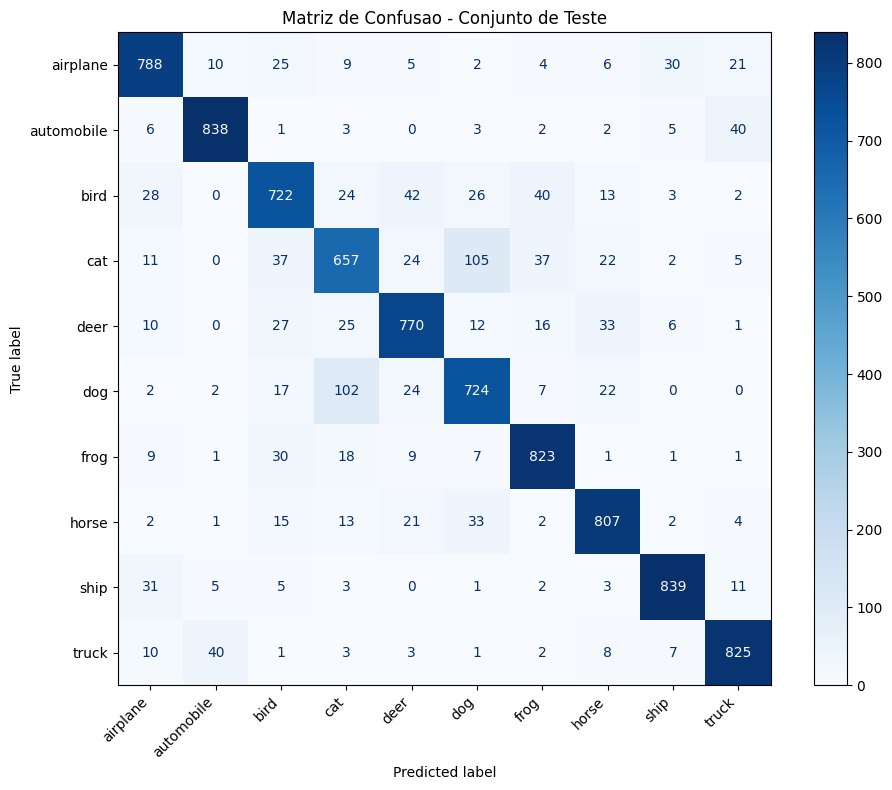


Classes com mais erros:
  airplane    : 788/900 corretos  confusoes: ship(30), bird(25)
  automobile  : 838/900 corretos  confusoes: truck(40), airplane(6)
  bird        : 722/900 corretos  confusoes: deer(42), frog(40)
  cat         : 657/900 corretos  confusoes: dog(105), bird(37)
  deer        : 770/900 corretos  confusoes: horse(33), bird(27)
  dog         : 724/900 corretos  confusoes: cat(102), deer(24)
  frog        : 823/900 corretos  confusoes: bird(30), cat(18)
  horse       : 807/900 corretos  confusoes: dog(33), deer(21)
  ship        : 839/900 corretos  confusoes: airplane(31), truck(11)
  truck       : 825/900 corretos  confusoes: automobile(40), airplane(10)


In [9]:
clfgen.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))
clfgen.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for images, labels in loader_test:
        images = images.to(DEVICE)
        preds  = clfgen(images).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(labels.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

test_acc = (all_preds == all_true).mean()
print(f'Acuracia no teste: {test_acc:.4f} ({test_acc*100:.2f}%)')

print('\nRelatorio por classe:')
print(classification_report(all_true, all_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(all_true, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Matriz de Confusao - Conjunto de Teste')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nClasses com mais erros:')
for i, cls in enumerate(CLASS_NAMES):
    row = cm[i]
    erros = [(CLASS_NAMES[j], row[j]) for j in range(len(CLASS_NAMES)) if j != i and row[j] > 0]
    erros.sort(key=lambda x: -x[1])
    top = ', '.join([f'{n}({c})' for n, c in erros[:2]])
    print(f'  {cls:<12}: {row[i]}/{row.sum()} corretos  confusoes: {top}')